# The desert campus isn't the burden hotspot

Merascope backlog piece, never sent to any press channel (`ej_score`/`water_score` are pipeline indicators, distinct from the water-stress finding already sent to Lisa Stiffler and the fire-risk finding held back for a possible future tip). Every confirmed, active (operating or under-construction) Washington data-center site, matched by exact point-in-polygon to its real ZCTA in merascope's own scored grid, pulling two of the pipeline's 22 real indicators: `ej_score` (EPA/state environmental-justice burden, higher = less burden) and `water_score` (PRISM 30-year precipitation, higher = more water availability).

The going-in assumption was that the two would track together — the water-scarce desert campuses (the ones that draw the water-consumption headlines) would also be the EJ hotspots. The self-check below says otherwise before any claim is made from it.

In [ ]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from shapely.geometry import shape, Point

DC_PATH = Path("../../merascope/data/shared/tracked_datacenters.geojson")
ZCTA_PATH = Path("../../merascope/data/WA/zcta/grid_scores.geojson")

dcs = json.loads(DC_PATH.read_text())["features"]
zctas = json.loads(ZCTA_PATH.read_text())["features"]
zcta_polys = [(shape(f["geometry"]), f["properties"]) for f in zctas]
print(f"loaded {len(dcs)} tracked sites, {len(zctas)} WA ZCTAs")

In [2]:
# Confirmed WA sites only (2+ independent sources per dc_tracker.py), active status
# only (operating/under_construction) -- proposed sites haven't broken ground and
# don't belong in a claim about where burden concentrates today.
rows = []
for f in dcs:
    p = f["properties"]
    if p["state"] != "WA" or not p["confirmed"] or p["status"] not in ("operating", "under_construction"):
        continue
    lon, lat = f["geometry"]["coordinates"]
    pt = Point(lon, lat)
    match = next((props for geom, props in zcta_polys if geom.contains(pt)), None)
    assert match is not None, f"{p['name']} did not land in any WA ZCTA -- check coordinates"
    rows.append({
        "name": p["name"], "city": p["city"], "zcta": match["zcta"],
        "ej_score": match["ej_score"], "water_score": match["water_score"],
    })

print(f"matched {len(rows)} confirmed active WA sites")
for r in rows:
    print(f"  {r['name']:35s} {r['city']:15s} zcta={r['zcta']}  ej={r['ej_score']:.3f}  water={r['water_score']:.3f}")

matched 10 confirmed active WA sites
  Microsoft Quincy Campus             Quincy          zcta=98848  ej=0.403  water=0.127
  Sabey SDC Quincy                    Quincy          zcta=98848  ej=0.403  water=0.127
  H5 Data Centers Quincy II           Quincy          zcta=98848  ej=0.403  water=0.127
  Microsoft EAT06/EAT09               East Wenatchee  zcta=98802  ej=0.664  water=0.253
  Microsoft Malaga Campus             Malaga          zcta=98828  ej=0.601  water=0.215
  Equinix SE2 Seattle                 Seattle         zcta=98121  ej=0.476  water=0.731
  Westin Building Exchange            Seattle         zcta=98121  ej=0.476  water=0.731
  Verizon Seattle                     Seattle         zcta=98101  ej=0.467  water=0.730
  HorizonIQ Seattle (Tukwila)         Tukwila         zcta=98168  ej=0.357  water=0.733
  ColoCrossing SEA1 (Tukwila)         Tukwila         zcta=98168  ej=0.357  water=0.733


In [3]:
# Aggregate to one point per real geographic cluster (city), not per ZCTA --
# Seattle downtown spans two adjacent ZCTAs (98121/98101) with near-identical
# scores, which produced two overlapping, unreadable labels. Site-count-weighted
# mean per city collapses that without hiding any site.
by_city = defaultdict(list)
for r in rows:
    by_city[r["city"]].append(r)

clusters = []
for city, sites in by_city.items():
    n = len(sites)
    clusters.append({
        "label": city,
        "n_sites": n,
        "ej_score": sum(s["ej_score"] for s in sites) / n,
        "water_score": sum(s["water_score"] for s in sites) / n,
    })
clusters.sort(key=lambda c: c["ej_score"])

# Self-check before any claim: is the lowest-EJ (most-burdened) cluster also a
# high-water one, not a water-scarce one? feedback_verify_before_asserting.
worst_ej = clusters[0]
best_water = max(clusters, key=lambda c: c["water_score"])
assert worst_ej["label"] == best_water["label"], "worst-EJ cluster is not the best-water cluster -- claim doesn't hold, don't post it"
driest = min(clusters, key=lambda c: c["water_score"])
assert worst_ej["ej_score"] < driest["ej_score"], "desert cluster isn't actually less burdened -- claim doesn't hold"
print(f"self-check passed: {worst_ej['label']} is both the worst-EJ AND best-water cluster")
print(f"driest cluster ({driest['label']}, water={driest['water_score']:.3f}) reads LESS EJ-burdened (ej={driest['ej_score']:.3f}) than {worst_ej['label']} (ej={worst_ej['ej_score']:.3f})")

self-check passed: Tukwila is both the worst-EJ AND best-water cluster
driest cluster (Quincy, water=0.127) reads LESS EJ-burdened (ej=0.403) than Tukwila (ej=0.357)


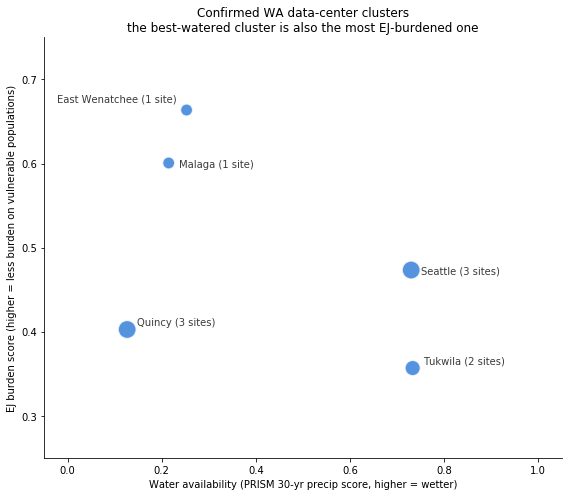

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))

sizes = [60 + 90 * c["n_sites"] for c in clusters]
xs = [c["water_score"] for c in clusters]
ys = [c["ej_score"] for c in clusters]
ax.scatter(xs, ys, s=sizes, color="#2a78d6", alpha=0.8, edgecolor="white", linewidth=1.5, zorder=3)

offsets = {
    "Tukwila": (10, 4), "Seattle": (10, -4), "Quincy": (10, 4),
    "East Wenatchee": (-10, 8), "Malaga": (10, -4),
}
for c in clusters:
    label = c["label"]
    dx, dy = offsets.get(label, (10, 4))
    ha = "right" if dx < 0 else "left"
    ax.annotate(f"{label} ({c['n_sites']} site{'s' if c['n_sites'] > 1 else ''})", (c["water_score"], c["ej_score"]),
                xytext=(dx, dy), textcoords="offset points", ha=ha, fontsize=10, color="#3a3a38")

ax.set_xlabel("Water availability (PRISM 30-yr precip score, higher = wetter)")
ax.set_ylabel("EJ burden score (higher = less burden on vulnerable populations)")
ax.set_title(
    "Confirmed WA data-center clusters\n"
    "the best-watered cluster is also the most EJ-burdened one",
    fontsize=12,
)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0.25, 0.75)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig("dc_ej_water_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

## Source & caption notes

- Data: merascope's own scored WA ZCTA pipeline (`ej_score`, `water_score`), matched by exact point-in-polygon against `tracked_datacenters.geojson`'s confirmed, active WA sites (2+ independent-source corroboration per `dc_tracker.py`). No invented composite -- both are real pipeline indicator columns. Seattle's two ZCTAs (98121, 98101) are site-count-weighted into one "Seattle" cluster point since their scores are nearly identical and plotting them separately just overlapped the labels.
- Going-in assumption: the water-scarce desert campuses (Quincy, East Wenatchee, Malaga -- the ones that draw water-consumption headlines) would also read as the EJ hotspots. They don't. Tukwila (2 confirmed sites: HorizonIQ, ColoCrossing) has the best water access of any WA cluster and the *worst* EJ score -- lower than Quincy's desert campus, which has the driest water score of any cluster.
- Not a claim that Quincy's water draw is fine -- that's a separate, real, already-covered concern (water stress is its own indicator, distinct from EJ burden). This is specifically about EJ/community burden, which runs the opposite direction from water in this dataset.
- n=5 city clusters -- too small for a correlation statistic, reported as a direct descriptive reversal, not an inferential claim.